In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

students = pd.read_csv('StudentsPerformance.csv')
students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
students_df = pd.DataFrame(students)
students_df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


C:\Users\mattm\AppData\Local\Temp\ipykernel_17644\463812085.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = students.groupby(["parental level of education", "math score bin"]).size().unstack() #the .size() counts the number of students in each group amd the .unstack() transforms the math score bin from rows to columns which creates a 2D table


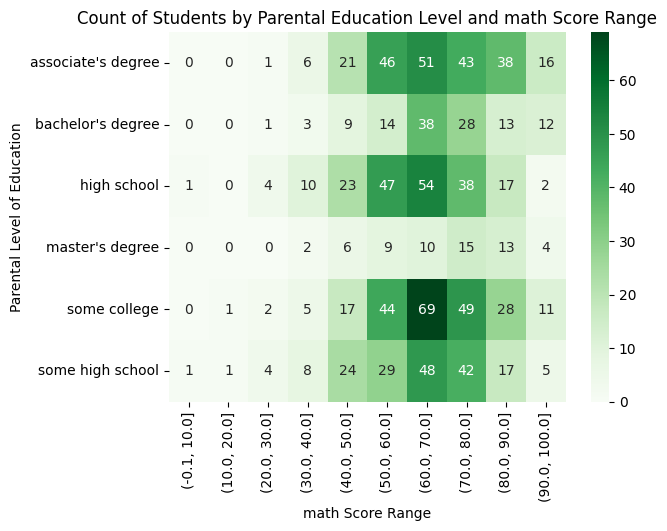

In [3]:
students["math score bin"] = pd.cut(students["math score"], bins=10) #this line creates a new column called math score bin which divides all the math scores into 10 equal width groups
#and the .cut() breaks continuous values like the math scores into categories. and after this each student is assigned a bin lable based on their scores.

count_data = students.groupby(["parental level of education", "math score bin"]).size().unstack() #the .size() counts the number of students in each group amd the .unstack() transforms the math score bin from rows to columns which creates a 2D table

sns.heatmap(count_data, cmap="Greens", annot=True, fmt="d") #counts_data is the 2D table itself, annot=True shows the count number in each cell. fmt tells seaborn to set each cell to interger and cmap sets the color of the graphs in shades
plt.title("Count of Students by Parental Education Level and math Score Range")
plt.xlabel("math Score Range")
plt.ylabel("Parental Level of Education")
plt.show()

<Figure size 1000x600 with 0 Axes>

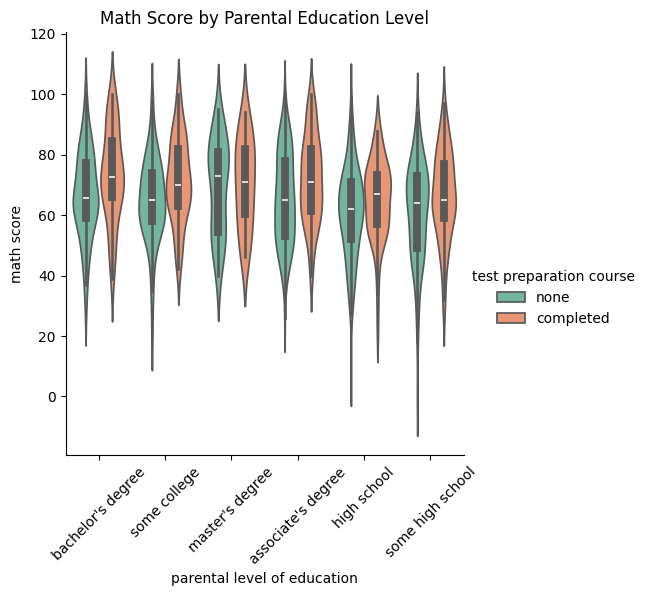

In [4]:
"""13. Generate a visualization that shows the correlation between all three test scores,
grouped by parental education level. Is parental education equally important for all
subjects?"""
plt.figure(figsize=(10,6))
sns.catplot(x='parental level of education',y='math score',hue='test preparation course',data=students_df,kind='violin',palette='Set2')
plt.xticks(rotation=45)
plt.title('Math Score by Parental Education Level')
plt.show()

<Figure size 1000x600 with 0 Axes>

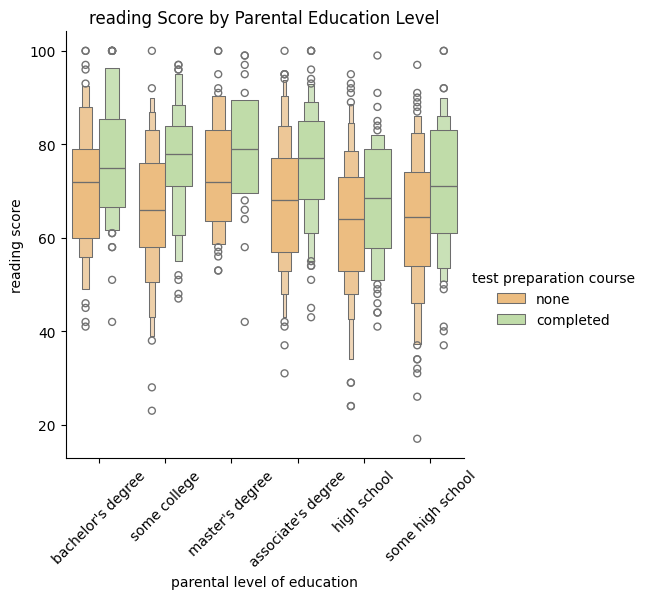

In [5]:
plt.figure(figsize=(10,6))
sns.catplot(x='parental level of education',y='reading score',hue='test preparation course',data=students_df,kind='boxen',palette='Spectral')
plt.xticks(rotation=45)
plt.title('reading Score by Parental Education Level')
plt.show()

<Figure size 1000x600 with 0 Axes>

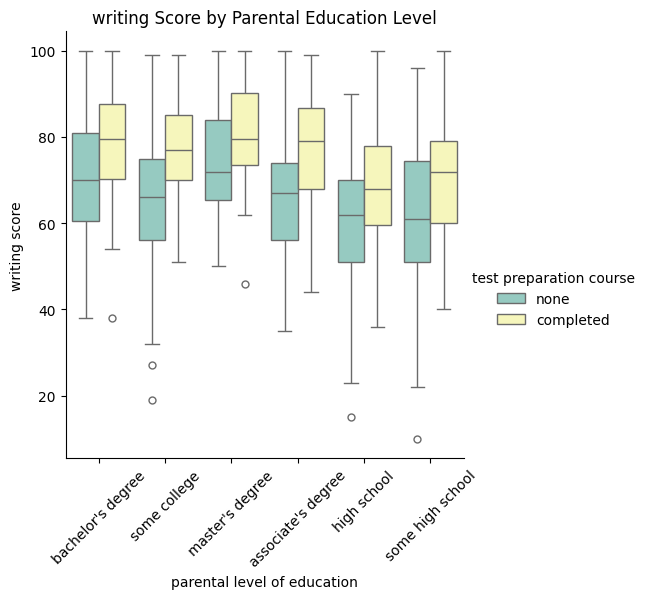

In [6]:
plt.figure(figsize=(10,6))
sns.catplot(x='parental level of education',y='writing score',hue='test preparation course',data=students_df,kind='box',palette='Set3')
plt.xticks(rotation=45)
plt.title('writing Score by Parental Education Level')
plt.show()

<Figure size 1000x1000 with 0 Axes>

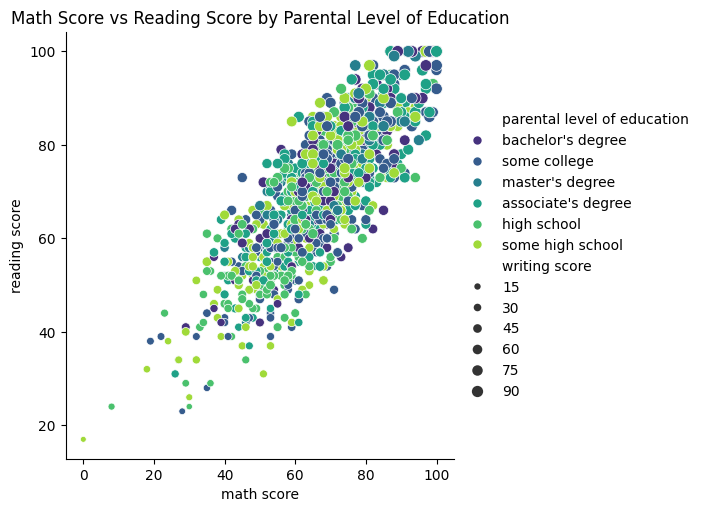

In [7]:
plt.figure(figsize=(10, 10))
sns.relplot(x='math score', y='reading score', hue='parental level of education', data=students_df, kind='scatter', size='writing score',palette='viridis')
plt.title('Math Score vs Reading Score by Parental Level of Education')
plt.show()


<Figure size 1000x1000 with 0 Axes>

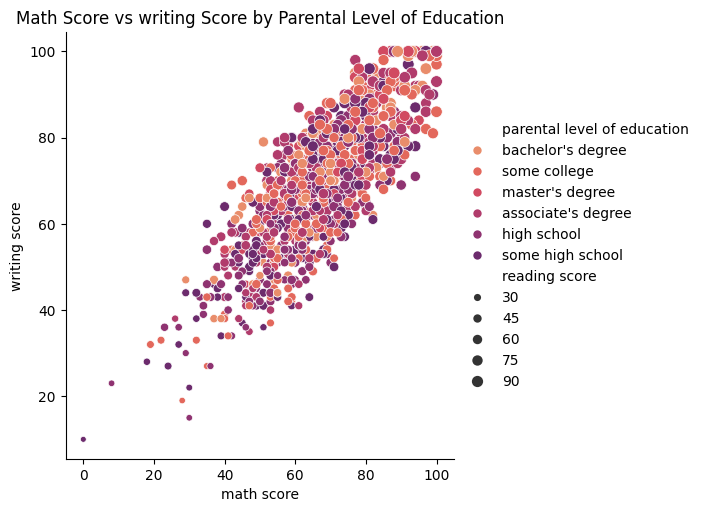

In [8]:
plt.figure(figsize=(10, 10))
sns.relplot(x='math score', y='writing score', hue='parental level of education', data=students_df, kind='scatter', size='reading score',palette='flare')
plt.title('Math Score vs writing Score by Parental Level of Education')
plt.show()

<Figure size 1000x1000 with 0 Axes>

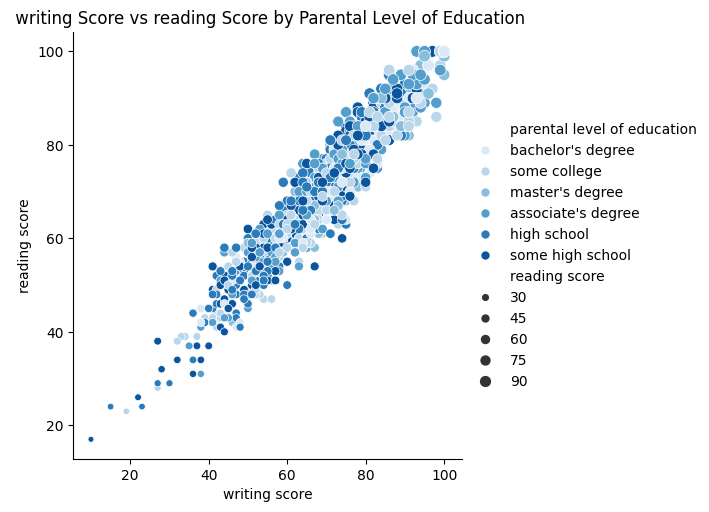

In [9]:
plt.figure(figsize=(10, 10))
sns.relplot(x='writing score', y='reading score', hue='parental level of education', data=students_df, kind='scatter', size='reading score',palette='Blues')
plt.title(' writing Score vs reading Score by Parental Level of Education')
plt.show()

<Figure size 1200x1200 with 0 Axes>

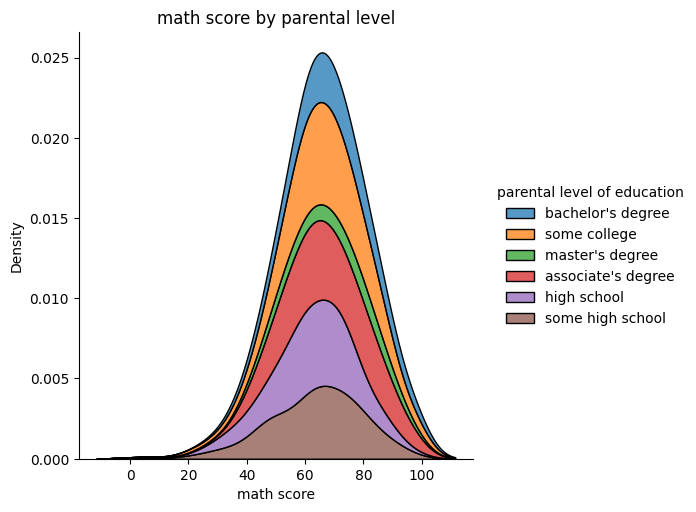

In [10]:
plt.figure(figsize=(12, 12))
sns.displot(x="math score" , hue="parental level of education", multiple="stack", kind="kde", data=students)
plt.title("math score by parental level")
plt.show()

<Figure size 1200x1200 with 0 Axes>

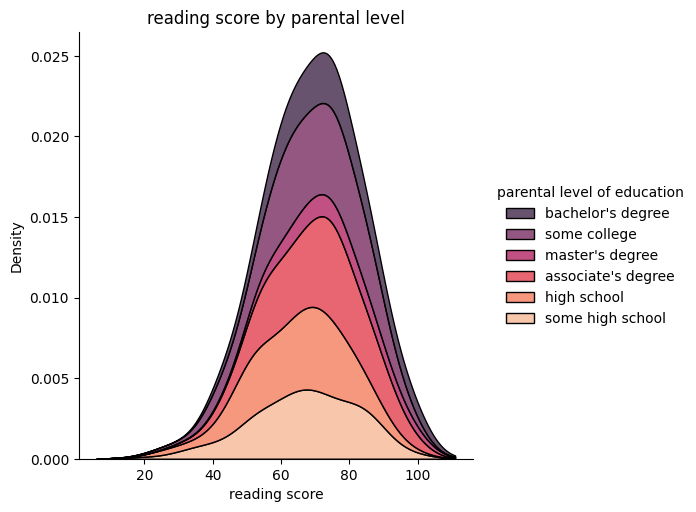

In [11]:
plt.figure(figsize=(12, 12))
sns.displot(x="reading score" , hue="parental level of education", multiple="stack", kind="kde", data=students,palette='rocket')
plt.title("reading score by parental level")
plt.show()

<Figure size 1200x1200 with 0 Axes>

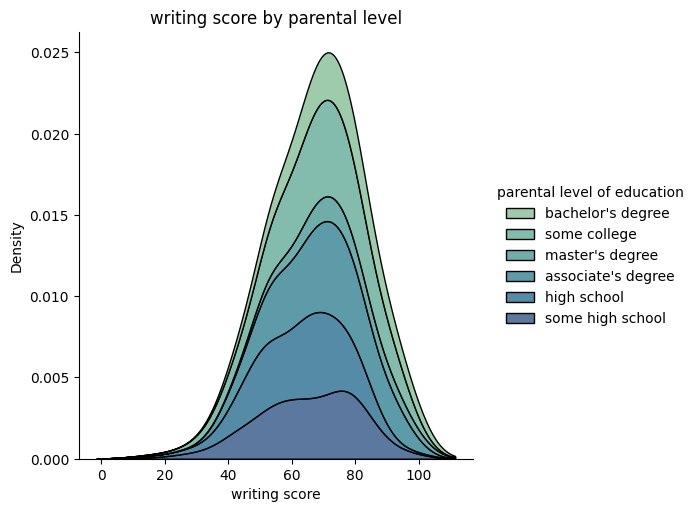

In [12]:
plt.figure(figsize=(12, 12))
sns.displot(x="writing score" , hue="parental level of education", multiple="stack", kind="kde", data=students ,palette='crest' )
plt.title("writing score by parental level")
plt.show()